In [1]:
using Revise
using ConjugateHeatTransfer
using CairoMakie
using LinearAlgebra
using QuadGK
using PolygonOps
using StaticArrays
using SpecialFunctions
γ = 0.577215664901532;

In [2]:
# Parameters
N_bie = 32; # number of points per slit for BIE
solve_quad(args...) = quadgk(args...; atol=1e-12, rtol=1e-12)[1];
plot_quad(args...) = quadgk(args...; atol=1e-6, rtol=1e-6)[1];

In [3]:
function solve_heat_transfer_circle(T, Pe)
    # Body
    bodies = [DirichletBody(0, θ->exp(im*θ), T)];
    # Solve potential flow
    # t0 = time();
    # W = aaa_potential_flow(bodies, Pe + (0+0im), 200, 20);
    # W = adaptive_laurent_potential_flow(bodies, Pe+0im; atol=1e-7);
    # println("Solved potential flow (", round(time()-t0, digits=3), " s)");
    # t0 = time();
    # reparametrize!(bodies, W; atol=1e-10);
    # println("Joukowsky reparametrization done (", round(time()-t0, digits=3), " s)");
    # Prescribe Joukowsky mapping
    W(z) = (z .+ 1 ./ z)
    bodies[1].θη = η -> η
    bodies[1].zη = bodies[1].zθ
    bodies[1].Tη = bodies[1].Tθ
    bodies[1].φmin = -2
    bodies[1].φmax = 2
    bodies[1].ψ = 0
    # Panels
    panels = [DirichletPanel(body) for body in bodies];
    t0 = time();
    solve_densities!(panels, N_bie; Pe=Pe, atol=1e-10, quadrature=solve_quad);
    println("Densities solved (", round(time()-t0, digits=3), " s)");
    return W, panels
end

solve_heat_transfer_circle (generic function with 1 method)

In [4]:
# Compute fluxes for a range of Peclet numbers
Pe_vec = collect(exp10.(LinRange(-6, 6, 13)));
m_vec = [0,1,2,3,4]
fluxes = Vector{Vector{Float64}}();
for m in m_vec
    flux = Vector{Float64}();
    for Pe in Pe_vec
        println("----------------------------------------------------------------")
        println("Solving for (m, Pe) = (", m, ", ", Pe, ")")
        W, panels = solve_heat_transfer_circle(θ->cos(m*θ), Pe);
        push!(flux, panels[1].flux)
        println("panels.SL_density = ", panels[1].SL_density)
        println("panels.flux = ", panels[1].flux)
    end
    push!(fluxes, flux)
end

----------------------------------------------------------------
Solving for (m, Pe) = (0, 1.0e-6)
  g coeffs: 0
size(M) = (64, 32)
cond(M) = 453.3622669275548
Densities solved (5.591 s)
panels.SL_density = Fun(Chebyshev(-2.0 .. 2.0), [0.136756, -1.86324e-6, -4.02385e-13, 3.99438e-16, 6.19162e-14, 1.01182e-15, 1.17083e-14, -9.61692e-16, 6.36274e-14, -3.47022e-15, -2.27885e-14, 2.05343e-15, -9.38378e-14, 4.47038e-15, -6.88456e-14, -3.10726e-16, 6.03308e-14, -5.60798e-16, 4.36183e-14, -1.6265e-15, 4.1152e-14, 6.43188e-16, 3.44081e-13, -1.80949e-15, -7.97395e-14, -3.10677e-15, -8.01878e-14, 2.50641e-15, -1.71797e-13, 1.4116e-14, 2.17992e-13, 6.12203e-15])
panels.flux = 0.42963157446205225
----------------------------------------------------------------
Solving for (m, Pe) = (0, 1.0e-5)
  g coeffs: 0
size(M) = (64, 32)
cond(M) = 381.98212907886165
Densities solved (0.786 s)
panels.SL_density = Fun(Chebyshev(-2.0 .. 2.0), [0.162311, -1.83769e-5, -4.3874e-11, 4.58735e-17, 3.35534e-14, -1.280

In [5]:
# Solve for temperature plots
Pe = 1;
Wc, pc = solve_heat_transfer_circle(θ->cos(4*θ), Pe);
Ws, ps = solve_heat_transfer_circle(θ->sin(4*θ), Pe);
bodies = [pc[1].body];

# Evaluate T(z)
Lz = 40.1;
gridsize = 400
x = collect(LinRange(-0.5*Lz, 1.5*Lz, gridsize));
y = collect(LinRange(-Lz, Lz, gridsize));
z = x' .+ im*y;

# Evaluate flow
t0 = time();
w = reshape(Wc(vec(z)), size(z));
println("Flow evaluated (", round(time()-t0, digits=3), " s)");

# Mask interiors before evaluating temperature
φ = real(w);
ψ = imag(w);
function check_inside(body, z)
    poly = body.zθ.(LinRange(0, 2π, 100))
    poly[end] = poly[1]
    poly = [[real(z), imag(z)] for z in poly]
    return inpolygon([real(z), imag(z)], poly; in=true, on=false, out=false)
end
for body in bodies
    check_body(z) = check_inside(body, z)
    interior = check_body.(z)
    φ[interior] .= NaN
    ψ[interior] .= NaN
end

# Evaluate temperature
t0 = time();
Tc = EvaluateSystem(φ, ψ, pc; Pe=Pe, quadrature=plot_quad);
Ts = EvaluateSystem(φ, ψ, ps; Pe=Pe, quadrature=plot_quad);
println("Temperature evaluated (", round(time()-t0, digits=3), " s)");

# Mask interiors
for body in bodies
    check_body(z) = check_inside(body, z)
    interior = check_body.(z)
    φ[interior] .= NaN
    ψ[interior] .= body.ψ
    Tc[interior] .= NaN
    Ts[interior] .= NaN
end

  g coeffs: 0
size(M) = (64, 32)
cond(M) = 39.003075951566466
Densities solved (0.883 s)
  g coeffs: 4
size(M) = (64, 32)
cond(M) = 39.003075951566466
Densities solved (4.856 s)
Flow evaluated (0.046 s)
Temperature evaluated (3.174 s)


In [6]:
using HypergeometricFunctions


function CC_old(j::Int)
    return HypergeometricFunctions.pFq([(1 - j)/2, -j/2], [1], 1) / factorial(j) / 2^j
end

function aa_old(n::Int, k::Int)
    m = n + k
    k == 0 && return 2*m
    s = 0.0
    for j in 1:k
        s += (-1)^j * CC_old(j) / 2^j * factorial(j) * factorial(m-k) / factorial(m-k+j) * aa_old(m-k+j, k-j)
    end
    return -s
end

function H(j::Int)
    s = 0.0
    for k in 1:j
        s += 1/k
    end
    return s
end

function cc_old(k::Int)
    s = 0.0
    for j in 0:div(k, 2)
        s += digamma(j+1) / 2^(k-2*j) / factorial(k-2*j) / factorial(j)^2 / 4^(2*j)
    end
    return -s
end

function Fm_old(m::Int, P::Real)
    m == 0 && return 2*pi / (log(P/8) + γ)
    s = 0.0
    for k in 0:m-1
        s += (-1)^(m-k) / 2^(m-k) * (CC_old(m-k)*(log(P/8) + H(m-k)) + cc_old(m-k)) * aa_old(m-k, k)
    end
    return -s / (log(P/8) + γ) * pi * P^m
end

Fm_old (generic function with 1 method)

In [7]:
Fm_old(1, 2e-5)

2.8866347252776868e-5

In [8]:
using HypergeometricFunctions


function CC(j::Int)
    return HypergeometricFunctions.pFq([(1 - j)/2, -j/2], [1], 1) / factorial(j)
end

function aa(n::Int, k::Int)
    m = n + k
    k == 0 && return 2*m
    s = 0.0
    for j in 1:k
        s += (-1)^j * CC(j) / 2^j * factorial(j) * factorial(m-k) / factorial(m-k+j) * aa(m-k+j, k-j)
    end
    return -s
end

function H(j::Int)
    s = 0.0
    for k in 1:j
        s += 1/k
    end
    return s
end

function cc(k::Int)
    s = 0.0
    for j in 0:div(k, 2)
        s += digamma(j+1) / factorial(k-2*j) / factorial(j)^2 / 2^(2*j)
    end
    return -s
end

function Fm(m::Int, P::Real)
    m == 0 && return 2*pi / (log(P/4) + γ)
    s = 0.0
    for k in 0:m-1
        s += (-1)^(m-k) / 2^(m-k) * (CC(m-k)*(log(P/4) + H(m-k)) + cc(m-k)) * aa(m-k, k)
    end
    return -s / (log(P/4) + γ) * pi * P^m
end

Fm (generic function with 1 method)

In [9]:
Fm(1, 1e-5)

2.8866347252776868e-5

m = 0, error = [-7.049243046596585, -5.910849114271023, -4.759708267349993, -3.608438025418936, -2.458136294962282, -1.3380803018423126, -0.6264514700656486, 0.007070615517342125, 9.633514285015486e-5, 9.92782251635328e-7, 9.983468842682255e-9, 9.995891052322351e-11, 9.998930058267237e-13]
m = 1, error = [5566.5048394760925, 9.987665345868962, 3.11482155759872, 2.547542889374974, 2.000940037087769, 1.5112969490665558, 0.4185494360027341, -0.10230571886554199, -0.002543139903261269, -7.587314030113464e-5, -2.3143095274841754e-6, -7.189429610018848e-8, -2.244612752719539e-9]
m = 2, error = [-5.2751890511192566e10, -2.3541588079656465e6, -489.87884186259214, 5.073505518573579, 4.151323623554662, 3.4336688347164084, -3.923398097914388, -1.8047894988267097, -0.36747950825155823, -0.10294716502576613, -0.030990684047995633, -0.009557039205279, -0.0029394256137879916]
m = 3, error = [9.999966072020525e11, 9.96806359058642e9, 2.1618393448067974e7, 387.68742415259084, 5.257939309549088, 4.51467

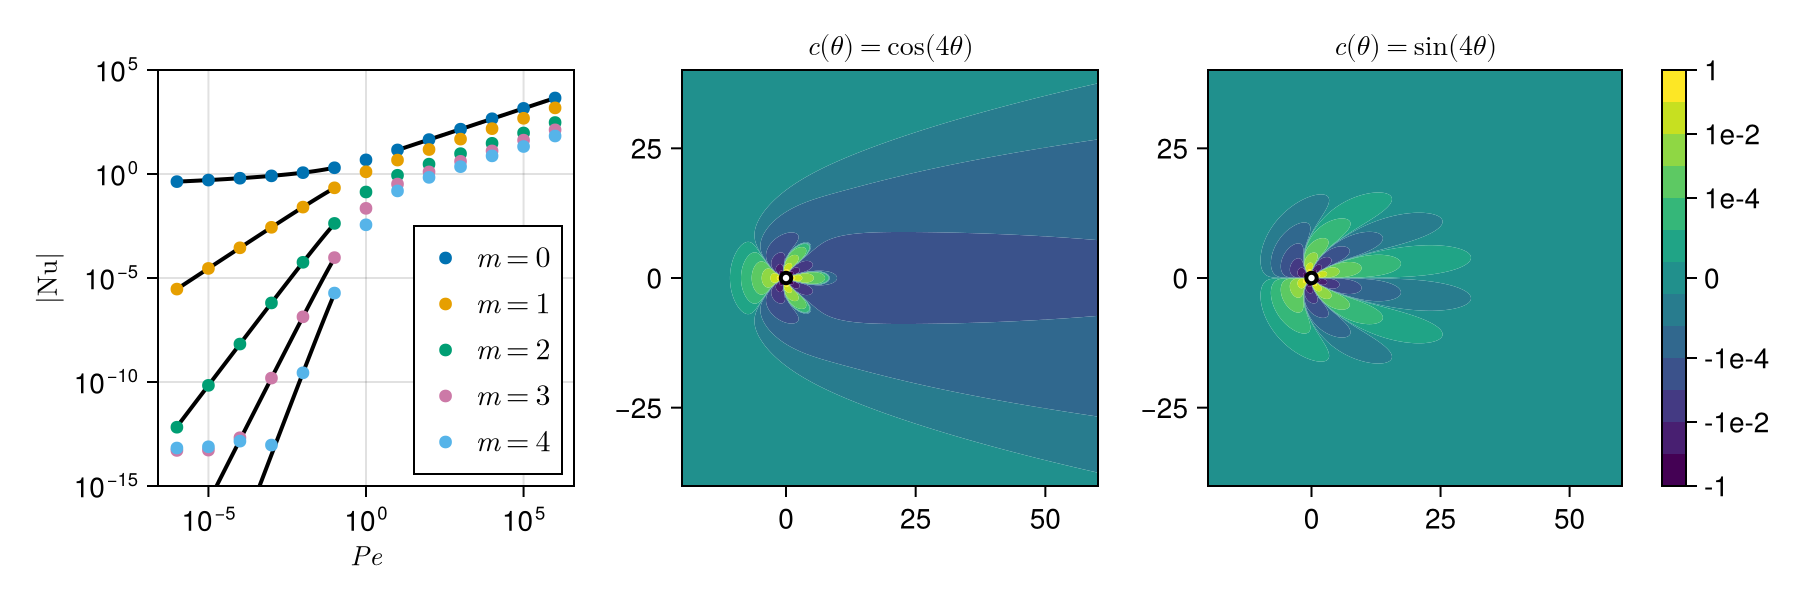

In [10]:
# Plot
fig = Figure(size=(900, 300));
set_theme!(theme_latexfonts());

# Levels
T_levels = 10.0 .^ collect(-6:0);
T_levels = vcat(-reverse(T_levels), T_levels);

# Left panel: fluxes
ax = Axis(fig[1,1], xscale=log10, yscale=log10, aspect=1);
# Low Peclet scaling
Pe_plot = 10 .^ LinRange(-6, -1, 100)
for (m, flux) in zip(m_vec, fluxes)
    lines!(ax, Pe_plot, abs.(Fm_old.(m, 2*Pe_plot)), linewidth=2, color=:black)
    println("m = ", m, ", error = ", (abs.(flux) .- abs.(Fm_old.(m, 2*Pe_vec))) ./ abs.(flux) ./ Pe_vec.^2)
end
# High Peclet scaling
Pe_plot = [1e1, 1e6]
lines!(ax, Pe_plot, 8/sqrt(pi) .* Pe_plot.^0.5, linewidth=2, color=:black)
#text!(ax, L"\sim \mathrm{Pe}^{1/2}", position=(1e1, 2e5), align=(:left, :top), color=:black, fontsize=16)
# Numerical fluxes
for (m, flux) in zip(m_vec, fluxes)
    scatter!(ax, Pe_vec, abs.(flux), marker=:circle, label=L"m=%$m", depthsorting=1);
    if flux[end] < 0
        println("flux negative for m = ", m)
    end
end
ylims!(ax, 1e-15, 1e5)
ax.xlabel = L"Pe"
ax.ylabel = L"|\mathrm{Nu}|"
axislegend(ax, labelsize=15, position=:rb);

# Plot temperature fields
function symlog(T; cutoff=1e-6)
    Tsym = log10(abs(T)/cutoff) + 0.5
    if Tsym < 0.5
        Tsym = abs(T) / cutoff / 2
    end
    return Tsym * sign(T)
end

ax1 = Axis(fig[1,2], aspect=DataAspect(), title=L"$c(\theta) = \cos(4\theta$)");
xlims!(ax1, -0.5*Lz, 1.5*Lz)
ylims!(ax1, -Lz, Lz)
poly!(ax1, [(-Lz, -Lz), (Lz, -Lz), (Lz, Lz), (-Lz, Lz)], color=:white, rasterize=true)
contourf!(ax1, x, y, symlog.(Tc'), levels=symlog.(T_levels), nan_color=:black);

ax2 = Axis(fig[1,3], aspect=DataAspect(), title=L"$c(\theta) = \sin(4\theta)$");
xlims!(ax2, -0.5*Lz, 1.5*Lz)
ylims!(ax2, -Lz, Lz)
poly!(ax2, [(-Lz, -Lz), (Lz, -Lz), (Lz, Lz), (-Lz, Lz)], color=:white, rasterize=true)
co = contourf!(ax2, x, y, symlog.(Ts'), levels=symlog.(T_levels), nan_color=:black);

# Bodies
colorrange = (T_levels[1], T_levels[end])
θp = LinRange(0, 2π, 100);
for body in bodies
    boundary = body.zθ.(θp)
    lines!(ax1, real(boundary), imag(boundary), color=:black, linewidth=2, colorrange=colorrange)
    lines!(ax2, real(boundary), imag(boundary), color=:black, linewidth=2, colorrange=colorrange)
end

ticks = [-1, -1e-1, -1e-2, -1e-3, -1e-4, -1e-5, 0, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1];
ticklabels = ["-1", "-1e-1", "-1e-2", "-1e-3", "-1e-4", "-1e-5", "0", "1e-5", "1e-4", "1e-3", "1e-2", "1e-1", "1"];
cb = Colorbar(fig[1,4], co; ticks=(ticks[1:2:end], ticklabels[1:2:end]));
cb.axis.attributes[:scale][] = symlog
cb.axis.attributes[:limits][] = [-1, 1]
save("fig_cosine_scalings.pdf", fig);
fig